In [163]:
    #              Raw iEEG Recording
    #                     │
    #                     ▼
    #          Remove bad channels
    #                     │
    #                     ▼
    #          Notch filter (50 Hz)
    #                     │
    #                     ▼
    #       Common Average Reference
    #                     │
    #                     ▼
    #  Resample to 512 Hz (if necessary)
    #                     │
    #                     ▼
    #   Split into Speech / Music / Rest epochs
    #                     │
    #                     ▼
    #    Group subjects by anatomy
    #                     │
    #                     ▼
    #       Compute Morlet TFR
    #                     │
    #                     ▼
    #   Average across epochs
    #                     │
    #                     ▼
    #   Average across channels
    #                     │
    #                     ▼
    #   Average across subjects
    #                     │
    #                     ▼
    #   Normalize using Rest (dB)
    #                     │
    #                     ▼
    #   Plot Time-Frequency Maps

In [164]:
# AVERAGING

# 6 Speech Epochs
#         │
#         ▼
# Average across epochs
#         │
#         ▼
# One TFR per channel
#         │
#         ▼
# Average channels
#         │
#         ▼
# One TFR per subject
#         │
#         ▼
# Average subjects
#         │
#         ▼
# One TFR for the anatomical group

In [80]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
import mne_bids
from mne_bids import BIDSPath

from scipy import stats

In [81]:
# -----------------------------
# Dataset information
# -----------------------------
bids_dir = Path(r"E:\IEEG-FMRI Dataset")

preprocess_dir = Path(r"E:\IEEG-FMRI-DATASET-ANALYSIS\preprocess")

subjects = mne_bids.get_entity_vals(bids_dir, "subject")

session = "iemu"
datatype = "ieeg"
acquisition = "clinical"

In [ ]:
# Load the preprocessed film recordings (in the memory)

preprocessed_film = {}

for subject in subjects:

    fif_file = preprocess_dir / f"sub-{subject}_film_preprocessed_raw.fif"

    if not fif_file.exists():
        print(f"Skipping subject {subject}: preprocessed file not found")
        continue

    raw = mne.io.read_raw_fif(        #It simply opens the saved .fif file and reconstructs an MNE Raw object in memory
        fif_file, 
        preload=True,                 #MNE immediately loads the signal data into RAM.
        verbose=False
    )

    preprocessed_film[subject] = raw

    print(
        f"Loaded subject {subject} | "
        f"{len(raw.ch_names)} channels | "
        f"{raw.info['sfreq']} Hz"
    )

Loaded subject 01 | 101 channels | 2048.0 Hz
Loaded subject 02 | 59 channels | 512.0 Hz
Loaded subject 03 | 101 channels | 512.0 Hz
Skipping subject 04: preprocessed file not found
Loaded subject 05 | 73 channels | 2048.0 Hz
Loaded subject 06 | 102 channels | 512.0 Hz
Loaded subject 07 | 55 channels | 512.0 Hz
Skipping subject 08: preprocessed file not found
Loaded subject 09 | 69 channels | 2048.0 Hz
Loaded subject 10 | 90 channels | 512.0 Hz
Skipping subject 11: preprocessed file not found
Loaded subject 12 | 64 channels | 2048.0 Hz
Loaded subject 13 | 94 channels | 512.0 Hz
Loaded subject 14 | 109 channels | 512.0 Hz
Skipping subject 15: preprocessed file not found
Loaded subject 16 | 103 channels | 512.0 Hz
Loaded subject 17 | 89 channels | 512.0 Hz
Loaded subject 18 | 61 channels | 512.0 Hz
Loaded subject 19 | 78 channels | 512.0 Hz
Loaded subject 20 | 88 channels | 512.0 Hz
Loaded subject 21 | 109 channels | 2048.0 Hz
Loaded subject 22 | 51 channels | 512.0 Hz
Loaded subject 23 |

In [83]:
# Resample film recordings
for subject in preprocessed_film:
    raw = preprocessed_film[subject]

    if raw.info["sfreq"] > 512:
        print(f"Resampling film subject {subject}...")
        raw.resample(512)

    preprocessed_film[subject] = raw


Resampling film subject 01...
Resampling film subject 05...
Resampling film subject 09...
Resampling film subject 12...
Resampling film subject 21...
Resampling film subject 23...
Resampling film subject 25...
Resampling film subject 30...
Resampling film subject 32...
Resampling film subject 36...
Resampling film subject 42...
Resampling film subject 51...
Resampling film subject 61...


In [84]:
raw.get_data()

array([[ 5.24932875e-05,  4.51858068e-05,  3.77208416e-05, ...,
        -1.49180996e-04, -1.51106229e-04, -1.50950626e-04],
       [-6.16668694e-05, -6.19478378e-05, -5.84167501e-05, ...,
        -1.92268097e-04, -1.97179455e-04, -2.00267023e-04],
       [-6.12762451e-05, -6.03121443e-05, -5.46250412e-05, ...,
        -1.35674723e-04, -1.33761656e-04, -1.33665468e-04],
       ...,
       [-1.79168710e-05, -2.64266928e-05, -3.49760594e-05, ...,
         1.33928415e-05,  1.09163857e-05,  8.71734665e-06],
       [ 9.24346896e-05,  8.94649202e-05,  8.56883853e-05, ...,
         2.03321906e-05,  1.98145590e-05,  1.81900032e-05],
       [ 1.01712038e-04,  1.14087459e-04,  1.13247886e-04, ...,
        -4.95102722e-04, -4.91301005e-04, -4.83958429e-04]])

In [ ]:
#Read events.tsv

film_events = {}

for subject in preprocessed_film.keys():
    ieeg_dir = bids_dir / f"sub-{subject}" / f"ses-{session}" / datatype

    event_files = sorted(ieeg_dir.glob("*task-film*_events.tsv"))

    if len(event_files) == 0:
        print(f"No event file found for subject {subject}")
        continue

    events = pd.read_csv(event_files[0], sep="\t")
    film_events[subject] = events
    print(f"Subject {subject}")
    print(events.head())
    print("-" * 50)

Subject 01
     onset  duration  trial_type  value
0   21.306       0.0  start task      9
1   21.325      30.0       music      2
2   51.325      30.0      speech      1
3   81.325      30.0       music      2
4  111.325      30.0      speech      1
--------------------------------------------------
Subject 02
     onset  duration  trial_type  value
0   39.562       0.0  start task      9
1   39.562      30.0       music      2
2   69.562      30.0      speech      1
3   99.562      30.0       music      2
4  129.562      30.0      speech      1
--------------------------------------------------
Subject 03
    onset  duration  trial_type  value
0   0.895     0.031  start task      9
1   0.926    29.992       music      2
2  30.918    30.000      speech      1
3  60.918    30.000       music      2
4  90.918    30.000      speech      1
--------------------------------------------------
Subject 05
     onset  duration  trial_type  value
0  115.429     0.017  start task      9
1  115.44

In [87]:
import numpy as np

mne_events = {}

for subject in preprocessed_film.keys():

    raw = preprocessed_film[subject]
    events = film_events[subject]

    # Keep only speech and music events
    events = events[events["trial_type"].isin(["speech", "music"])]

    # Convert onset (seconds) to sample numbers
    samples = (events["onset"] * raw.info["sfreq"]).astype(int)

    # Event IDs
    event_ids = events["value"].astype(int)

    # MNE expects: [sample, previous_value, event_id]
    event_array = np.column_stack([
        samples,
        np.zeros(len(samples), dtype=int),
        event_ids
    ])

    mne_events[subject] = event_array

    print(f"\nSubject {subject}")
    print(event_array[:5])


Subject 01
[[10918     0     2]
 [26278     0     1]
 [41638     0     2]
 [56998     0     1]
 [72358     0     2]]

Subject 02
[[20255     0     2]
 [35615     0     1]
 [50975     0     2]
 [66335     0     1]
 [81695     0     2]]

Subject 03
[[  474     0     2]
 [15830     0     1]
 [31190     0     2]
 [46550     0     1]
 [61910     0     2]]

Subject 05
[[ 59108      0      2]
 [ 74467      0      1]
 [ 89827      0      2]
 [105187      0      1]
 [120547      0      2]]

Subject 06
[[ 2716     0     2]
 [18067     0     1]
 [33428     0     2]
 [48791     0     1]
 [64152     0     2]]

Subject 07
[[ 6240     0     2]
 [21600     0     1]
 [36960     0     2]
 [52320     0     1]
 [67680     0     2]]

Subject 09
[[ 6565     0     2]
 [21925     0     1]
 [37288     0     2]
 [52651     0     1]
 [68014     0     2]]

Subject 10
[[  373     0     2]
 [15730     0     1]
 [31090     0     2]
 [46450     0     1]
 [61810     0     2]]

Subject 12
[[21928     0     2]
 [37289 

In [169]:
print("Film sampling rates:")
for subject in sorted(preprocessed_film):
    print(subject, preprocessed_film[subject].info["sfreq"])

print("\nRest sampling rates:")
for subject in sorted(preprocessed_rest):
    print(subject, preprocessed_rest[subject].info["sfreq"])

Film sampling rates:
01 512.0
02 512.0
03 512.0
05 512.0
06 512.0
07 512.0
09 512.0
10 512.0
12 512.0
13 512.0
14 512.0
16 512.0
17 512.0
18 512.0
19 512.0
20 512.0
21 512.0
22 512.0
23 512.0
24 512.0
25 512.0
26 512.0
27 512.0
28 512.0
30 512.0
31 512.0
32 512.0
33 512.0
34 512.0
36 512.0
37 512.0
38 512.0
39 512.0
40 512.0
41 512.0
42 512.0
43 512.0
45 512.0
46 512.0
48 512.0
49 512.0
50 512.0
51 512.0
54 512.0
55 512.0
57 512.0
58 512.0
59 512.0
60 512.0
61 512.0
63 512.0

Rest sampling rates:
01 512.0
02 512.0
03 512.0
05 512.0
06 512.0
07 512.0
09 512.0
10 512.0
12 512.0
13 512.0
14 512.0
16 512.0
17 512.0
18 512.0
19 512.0
20 512.0
21 512.0
22 512.0
23 512.0
24 512.0
25 512.0
26 512.0
27 512.0
28 512.0
30 512.0
31 512.0
32 512.0
34 512.0
36 512.0
37 512.0
38 512.0
39 512.0
40 512.0
41 512.0
42 512.0
43 512.0
45 512.0
46 512.0
48 512.0
49 512.0
50 512.0
51 512.0
54 512.0
55 512.0
57 512.0
58 512.0
59 512.0
60 512.0
61 512.0
63 512.0


In [ ]:
#Create epochs for speech and music

speech_music_epochs = {}

event_id = {
    "speech": 1,
    "music": 2
}

for subject in sorted(preprocessed_film.keys()):

    if subject not in mne_events:
        continue

    raw = preprocessed_film[subject]
    events = mne_events[subject]

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=30,
        baseline=None,            #Do not perform baseline correction while creating the epochs.
        preload=True,
        verbose=False
    )

    speech_music_epochs[subject] = epochs

    print(
        f"Subject {subject}: "
        f"{len(epochs['speech'])} speech epochs, "
        f"{len(epochs['music'])} music epochs"
    )

Subject 01: 6 speech epochs, 7 music epochs
Subject 02: 6 speech epochs, 7 music epochs
Subject 03: 6 speech epochs, 7 music epochs
Subject 05: 6 speech epochs, 7 music epochs
Subject 06: 6 speech epochs, 7 music epochs
Subject 07: 6 speech epochs, 7 music epochs
Subject 09: 6 speech epochs, 7 music epochs
Subject 10: 6 speech epochs, 7 music epochs
Subject 12: 6 speech epochs, 7 music epochs
Subject 13: 6 speech epochs, 7 music epochs
Subject 14: 6 speech epochs, 7 music epochs
Subject 16: 6 speech epochs, 7 music epochs
Subject 17: 6 speech epochs, 7 music epochs
Subject 18: 6 speech epochs, 7 music epochs
Subject 19: 6 speech epochs, 7 music epochs
Subject 20: 6 speech epochs, 7 music epochs
Subject 21: 6 speech epochs, 7 music epochs
Subject 22: 6 speech epochs, 7 music epochs
Subject 23: 6 speech epochs, 7 music epochs
Subject 24: 6 speech epochs, 7 music epochs
Subject 25: 6 speech epochs, 7 music epochs
Subject 26: 6 speech epochs, 7 music epochs
Subject 27: 6 speech epochs, 7 m

In [171]:
from pathlib import Path

for f in sorted(preprocess_dir.glob("*.fif")):
    print(f.name)

sub-01_film_preprocessed_raw.fif
sub-01_rest_preprocessed_raw.fif
sub-02_film_preprocessed_raw.fif
sub-02_rest_preprocessed_raw.fif
sub-03_film_preprocessed_raw.fif
sub-03_rest_preprocessed_raw.fif
sub-05_film_preprocessed_raw.fif
sub-05_rest_preprocessed_raw.fif
sub-06_film_preprocessed_raw.fif
sub-06_rest_preprocessed_raw.fif
sub-07_film_preprocessed_raw.fif
sub-07_rest_preprocessed_raw.fif
sub-09_film_preprocessed_raw.fif
sub-09_rest_preprocessed_raw.fif
sub-10_film_preprocessed_raw.fif
sub-10_rest_preprocessed_raw.fif
sub-12_film_preprocessed_raw.fif
sub-12_rest_preprocessed_raw.fif
sub-13_film_preprocessed_raw.fif
sub-13_rest_preprocessed_raw.fif
sub-14_film_preprocessed_raw.fif
sub-14_rest_preprocessed_raw.fif
sub-16_film_preprocessed_raw.fif
sub-16_rest_preprocessed_raw.fif
sub-17_film_preprocessed_raw.fif
sub-17_rest_preprocessed_raw.fif
sub-18_film_preprocessed_raw.fif
sub-18_rest_preprocessed_raw.fif
sub-19_film_preprocessed_raw.fif
sub-19_rest_preprocessed_raw.fif
sub-20_fil

In [12]:
rest_files = sorted(preprocess_dir.glob("*rest*.fif"))

print(f"Number of rest files: {len(rest_files)}")

for f in rest_files:
    print(f.name)

Number of rest files: 50
sub-01_rest_preprocessed_raw.fif
sub-02_rest_preprocessed_raw.fif
sub-03_rest_preprocessed_raw.fif
sub-05_rest_preprocessed_raw.fif
sub-06_rest_preprocessed_raw.fif
sub-07_rest_preprocessed_raw.fif
sub-09_rest_preprocessed_raw.fif
sub-10_rest_preprocessed_raw.fif
sub-12_rest_preprocessed_raw.fif
sub-13_rest_preprocessed_raw.fif
sub-14_rest_preprocessed_raw.fif
sub-16_rest_preprocessed_raw.fif
sub-17_rest_preprocessed_raw.fif
sub-18_rest_preprocessed_raw.fif
sub-19_rest_preprocessed_raw.fif
sub-20_rest_preprocessed_raw.fif
sub-21_rest_preprocessed_raw.fif
sub-22_rest_preprocessed_raw.fif
sub-23_rest_preprocessed_raw.fif
sub-24_rest_preprocessed_raw.fif
sub-25_rest_preprocessed_raw.fif
sub-26_rest_preprocessed_raw.fif
sub-27_rest_preprocessed_raw.fif
sub-28_rest_preprocessed_raw.fif
sub-30_rest_preprocessed_raw.fif
sub-31_rest_preprocessed_raw.fif
sub-32_rest_preprocessed_raw.fif
sub-34_rest_preprocessed_raw.fif
sub-36_rest_preprocessed_raw.fif
sub-37_rest_prepro

In [172]:
from pathlib import Path

for subject in ["01", "02", "03"]:

    ieeg_dir = bids_dir / f"sub-{subject}" / f"ses-{session}" / datatype

    print(f"\nSubject {subject}")

    for f in sorted(ieeg_dir.glob("*rest*")):
        print(f.name)


Subject 01
sub-01_ses-iemu_task-rest_acq-clinical_run-1_channels.tsv
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.eeg
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.json
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vhdr
sub-01_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vmrk
sub-01_ses-iemu_task-rest_run-1_events.tsv

Subject 02
sub-02_ses-iemu_task-rest_acq-clinical_run-1_channels.tsv
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.eeg
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.json
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vhdr
sub-02_ses-iemu_task-rest_acq-clinical_run-1_ieeg.vmrk
sub-02_ses-iemu_task-rest_run-1_events.tsv

Subject 03
sub-03_ses-iemu_task-rest_acq-clinical_run-4_channels.tsv
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.eeg
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.json
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.vhdr
sub-03_ses-iemu_task-rest_acq-clinical_run-4_ieeg.vmrk
sub-03_ses-iemu_task-rest_run-4_events.tsv


In [173]:
#Load all the preprocessed rest FIF files

preprocessed_rest = {}

for subject in subjects:

    fif_file = preprocess_dir / f"sub-{subject}_rest_preprocessed_raw.fif"

    if not fif_file.exists():
        continue

    raw = mne.io.read_raw_fif(
        fif_file,
        preload=True,
        verbose=False
    )

    preprocessed_rest[subject] = raw

print(f"Loaded rest recordings for {len(preprocessed_rest)} subjects.")

Loaded rest recordings for 50 subjects.


In [174]:
# Resample resting-state recordings
for subject in preprocessed_rest:
    raw = preprocessed_rest[subject]

    if raw.info["sfreq"] > 512:
        print(f"Resampling rest subject {subject}...")
        raw = raw.copy().resample(512)

    preprocessed_rest[subject] = raw

Resampling rest subject 01...
Resampling rest subject 02...
Resampling rest subject 05...
Resampling rest subject 09...
Resampling rest subject 12...
Resampling rest subject 21...
Resampling rest subject 23...
Resampling rest subject 25...
Resampling rest subject 30...
Resampling rest subject 32...
Resampling rest subject 34...
Resampling rest subject 36...
Resampling rest subject 39...
Resampling rest subject 42...
Resampling rest subject 51...
Resampling rest subject 57...
Resampling rest subject 58...
Resampling rest subject 59...
Resampling rest subject 61...


In [99]:
print(len(preprocessed_rest))

50


In [154]:
# Create Rest Epochs

rest_epochs = {}

for subject in sorted(preprocessed_rest.keys()):

    raw = preprocessed_rest[subject]

    sfreq = raw.info["sfreq"]

    events = np.array([
        [int(start * sfreq), 0, 1]
        for start in range(0, 180, 30)
    ])

    event_id = {"rest": 1}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=30,
        baseline=None,
        preload=True,
        verbose=False,
    )

    rest_epochs[subject] = epochs

    print(f"Subject {subject}: {len(epochs)} rest epochs")

Subject 01: 6 rest epochs
Subject 02: 6 rest epochs
Subject 03: 6 rest epochs
Subject 05: 6 rest epochs
Subject 06: 6 rest epochs
Subject 07: 6 rest epochs
Subject 09: 6 rest epochs
Subject 10: 6 rest epochs
Subject 12: 6 rest epochs
Subject 13: 6 rest epochs
Subject 14: 6 rest epochs
Subject 16: 6 rest epochs
Subject 17: 6 rest epochs
Subject 18: 6 rest epochs
Subject 19: 6 rest epochs
Subject 20: 6 rest epochs
Subject 21: 6 rest epochs
Subject 22: 6 rest epochs
Subject 23: 6 rest epochs
Subject 24: 6 rest epochs
Subject 25: 6 rest epochs
Subject 26: 6 rest epochs
Subject 27: 6 rest epochs
Subject 28: 6 rest epochs
Subject 30: 6 rest epochs
Subject 31: 6 rest epochs
Subject 32: 6 rest epochs
Subject 34: 6 rest epochs
Subject 36: 6 rest epochs
Subject 37: 6 rest epochs
Subject 38: 6 rest epochs
Subject 39: 6 rest epochs
Subject 40: 6 rest epochs
Subject 41: 6 rest epochs
Subject 42: 6 rest epochs
Subject 43: 6 rest epochs
Subject 45: 6 rest epochs
Subject 46: 6 rest epochs
Subject 48: 

In [156]:
# ======================================
# Create rest dictionaries for ALL groups
# ======================================

group_rest_epochs = {}

for group_name, subject_list in groups.items():

    group_rest_epochs[group_name] = {}

    for subject in subject_list:

        sub = subject.replace("sub-", "")

        if sub in rest_epochs:
            group_rest_epochs[group_name][sub] = rest_epochs[sub]

print("\nResting-state subjects per group:\n")

for group_name in group_rest_epochs:
    print(f"{group_name}: {len(group_rest_epochs[group_name])}")


Resting-state subjects per group:

Temporal: 22
Fronto-Parietal: 10
Frontal: 12
Depth: 5
Mixed: 1


In [ ]:
# whats thi below code for defining frequencies??

In [ ]:
# Compute TFR for one subject

In [ ]:
import numpy as np

# -----------------------------
# Select group and subject
# -----------------------------
group_name = "Temporal"            #since subject 16 belongs to temporal group
subject = "16"

# -----------------------------
# Get epochs
# -----------------------------
speech_epochs = speech_music_epochs[subject]["speech"]
music_epochs  = speech_music_epochs[subject]["music"]
rest_epochs   = group_rest_epochs[group_name][subject]

# -----------------------------
# Morlet parameters
# -----------------------------
freqs = np.linspace(1, 120, 60)
n_cycles = freqs / 2

# -----------------------------
# Compute Speech TFR
# -----------------------------
speech_tfr = speech_epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=4,
    verbose=False
)

# -----------------------------
# Compute Music TFR
# -----------------------------
music_tfr = music_epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=4,
    verbose=False
)

# -----------------------------
# Compute Rest TFR
# -----------------------------
rest_tfr = rest_epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=False,
    decim=4,
    verbose=False
)

print("Speech:", speech_tfr.data.shape)
print("Music :", music_tfr.data.shape)
print("Rest  :", rest_tfr.data.shape)

Speech: (103, 60, 3841)
Music : (103, 60, 3841)
Rest  : (103, 60, 3841)


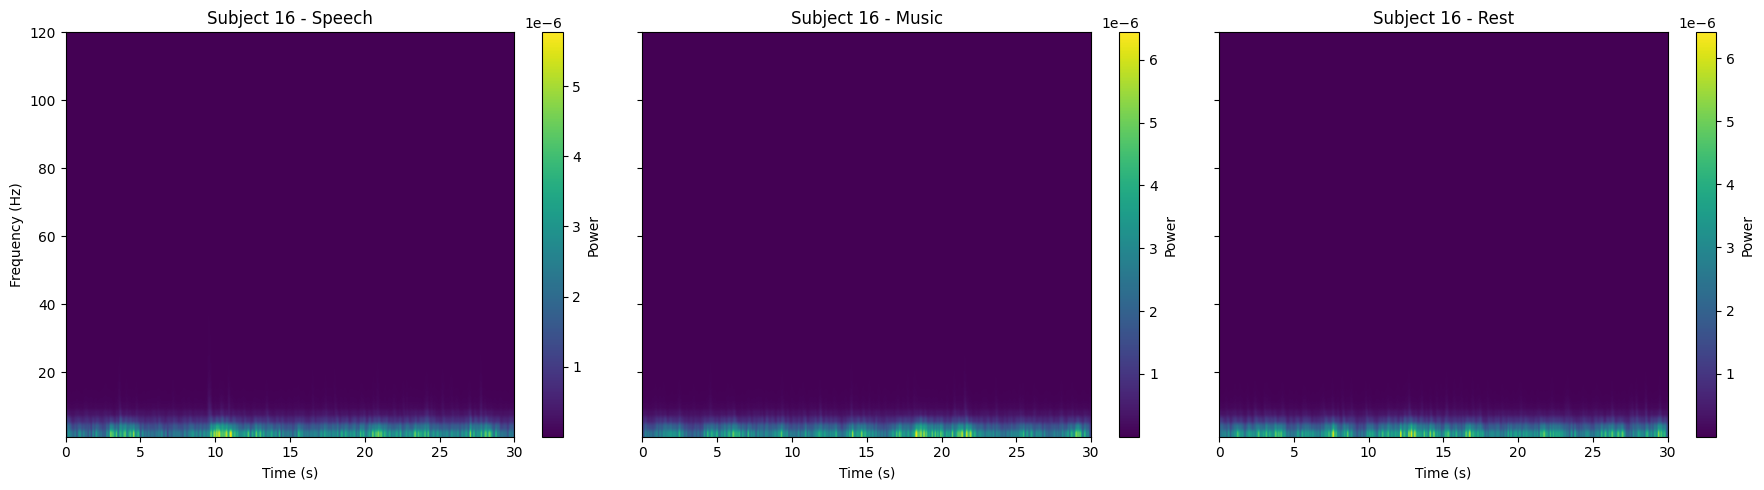

In [177]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Average across channels
# -----------------------------
speech_avg = speech_tfr.data.mean(axis=0)
music_avg  = music_tfr.data.mean(axis=0)
rest_avg   = rest_tfr.data.mean(axis=0)

times = speech_tfr.times
freqs = speech_tfr.freqs

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Speech
im1 = axes[0].imshow(
    speech_avg,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
)
axes[0].set_title(f"Subject {subject} - Speech")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
plt.colorbar(im1, ax=axes[0], label="Power")

# Music
im2 = axes[1].imshow(
    music_avg,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
)
axes[1].set_title(f"Subject {subject} - Music")
axes[1].set_xlabel("Time (s)")
plt.colorbar(im2, ax=axes[1], label="Power")

# Rest
im3 = axes[2].imshow(
    rest_avg,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
)
axes[2].set_title(f"Subject {subject} - Rest")
axes[2].set_xlabel("Time (s)")
plt.colorbar(im3, ax=axes[2], label="Power")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Compute TFRs for all TEMPORAL SUBJECTS
# ==========================================

speech_tfr_data = {}
music_tfr_data = {}
rest_tfr_data = {}

template_tfr = None  # we'll keep one TFR object as a template

for subject in sorted(temporal_subjects):

    subject = subject.replace("sub-", "")

    print(f"Processing Subject {subject}...")

    speech_epochs = speech_music_epochs[subject]["speech"]
    music_epochs  = speech_music_epochs[subject]["music"]
    rest_epochs   = temporal_rest_epochs[subject]

    speech_tfr = speech_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,       #epoch averaging happens here. 
                            # if i print speech_tfr.data.shape here, 
                            # output is (101, 60, 3841), where 101 is the number of channels (axis 0), 60 is the no. of freqs (axis 1), 
                            # and 3841 is the time (since decim = 4, so 15360/4)
        return_itc=False,
        decim=4,
        verbose=False,
    )

    music_tfr = music_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    rest_tfr = rest_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    # Save only the NumPy arrays
    # speech_tfr_data[subject] = speech_tfr.data.copy()
    # music_tfr_data[subject]  = music_tfr.data.copy()
    # rest_tfr_data[subject]   = rest_tfr.data.copy()

    speech_tfr_data[subject] = speech_tfr.data.mean(axis=0) #channel averaging happens here. it means "Take the average across all channels."
    music_tfr_data[subject]  = music_tfr.data.mean(axis=0)
    rest_tfr_data[subject]   = rest_tfr.data.mean(axis=0)

    # Keep one template for plotting later
    if template_tfr is None:
        template_tfr = speech_tfr.copy()

    # Free memory immediately
    del speech_tfr
    del music_tfr
    del rest_tfr

    print(f"✓ Finished Subject {subject}")

print("\nAll temporal subjects processed successfully!")

Processing Subject 16...
✓ Finished Subject 16
Processing Subject 17...
✓ Finished Subject 17
Processing Subject 20...
✓ Finished Subject 20
Processing Subject 22...
✓ Finished Subject 22
Processing Subject 24...
✓ Finished Subject 24
Processing Subject 26...
✓ Finished Subject 26
Processing Subject 27...
✓ Finished Subject 27
Processing Subject 28...
✓ Finished Subject 28
Processing Subject 34...
✓ Finished Subject 34
Processing Subject 36...
✓ Finished Subject 36
Processing Subject 39...
✓ Finished Subject 39
Processing Subject 40...
✓ Finished Subject 40
Processing Subject 45...
✓ Finished Subject 45
Processing Subject 46...
✓ Finished Subject 46
Processing Subject 48...
✓ Finished Subject 48
Processing Subject 49...
✓ Finished Subject 49
Processing Subject 51...
✓ Finished Subject 51
Processing Subject 54...
✓ Finished Subject 54
Processing Subject 57...
✓ Finished Subject 57
Processing Subject 58...
✓ Finished Subject 58
Processing Subject 59...
✓ Finished Subject 59
Processing Su

In [179]:
print(len(speech_epochs.times))
print(len(speech_tfr.times))
print(speech_epochs.times[-1], speech_tfr.times[-1])

15361
3841
30.0 30.0


In [ ]:
import numpy as np

speech_all = np.stack(list(speech_tfr_data.values()), axis=0)
music_all  = np.stack(list(music_tfr_data.values()), axis=0)
rest_all   = np.stack(list(rest_tfr_data.values()), axis=0)

print("Speech:", speech_all.shape)
print("Music :", music_all.shape)
print("Rest  :", rest_all.shape)
#the shape doesnt show 101 or some other no.(i.e. the no. of channels)
# since it is averaged over channels

Speech: (22, 60, 3841)
Music : (22, 60, 3841)
Rest  : (22, 60, 3841)


In [ ]:
#Averaging across all subjects
speech_group_avg = speech_all.mean(axis=0) #axis 0 here is the no. of subjects (as shown in above shape above)
music_group_avg  = music_all.mean(axis=0)
rest_group_avg   = rest_all.mean(axis=0)

In [ ]:
speech_group_avg.shape  

(60, 3841)

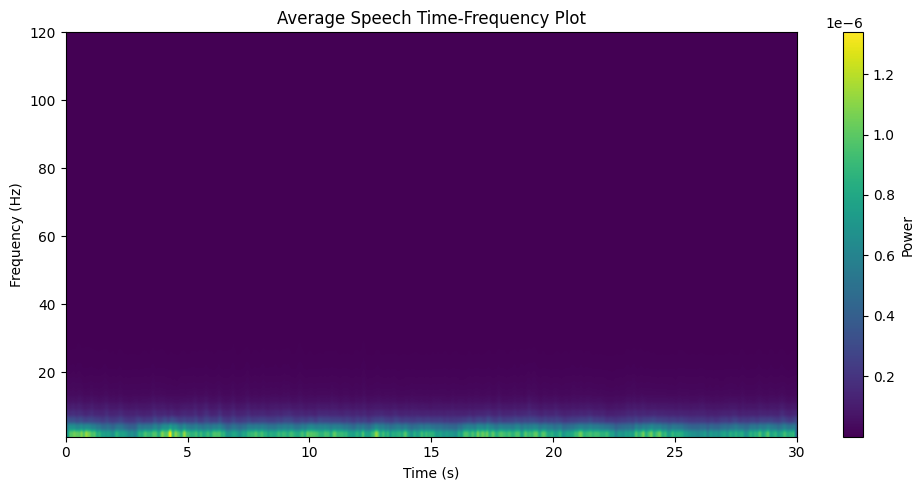

In [114]:
import matplotlib.pyplot as plt

vmin = min(speech_group_avg.min(), music_group_avg.min())
vmax = max(speech_group_avg.max(), music_group_avg.max())

plt.figure(figsize=(10, 5))

plt.imshow(
    speech_group_avg,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Speech Time-Frequency Plot")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

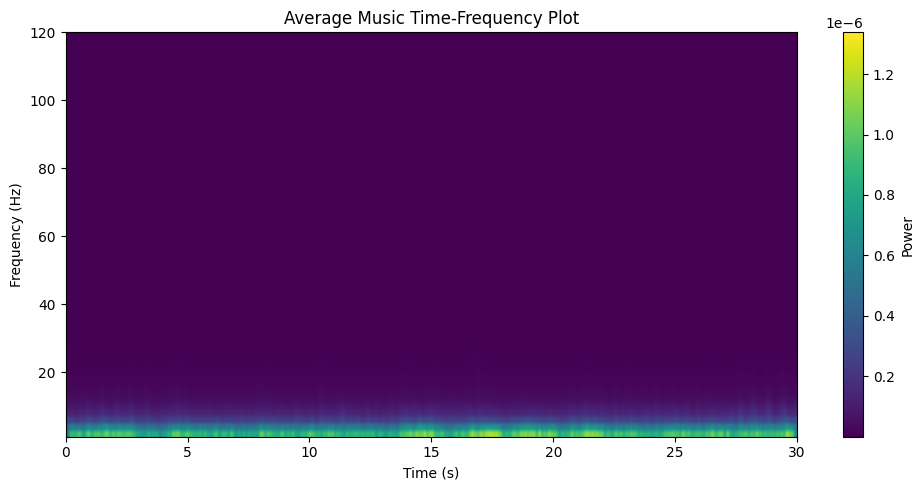

In [115]:
plt.figure(figsize=(10, 5))

plt.imshow(
    music_group_avg,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Music Time-Frequency Plot")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

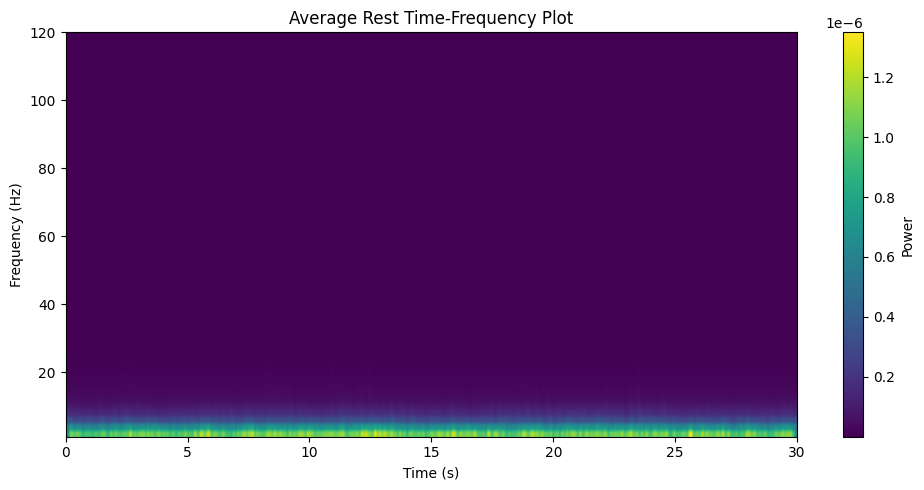

In [119]:
import matplotlib.pyplot as plt

# Common color scale across all three conditions
vmin = min(
    speech_group_avg.min(),
    music_group_avg.min(),
    rest_group_avg.min()
)

vmax = max(
    speech_group_avg.max(),
    music_group_avg.max(),
    rest_group_avg.max()
)

plt.figure(figsize=(10, 5))

plt.imshow(
    rest_group_avg,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    vmin=vmin,
    vmax=vmax,
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Rest Time-Frequency Plot")
plt.colorbar(label="Power")
plt.tight_layout()
plt.show()

In [123]:
# Mean resting-state power for each frequency
rest_baseline = rest_group_avg.mean(axis=1, keepdims=True)

print(rest_baseline.shape)

(60, 1)


In [124]:
speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

In [125]:
speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

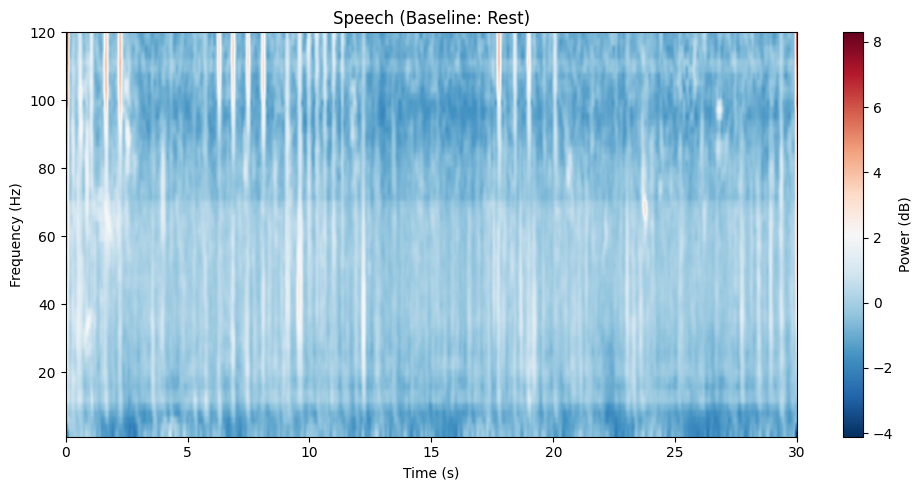

In [126]:
plt.figure(figsize=(10,5))

plt.imshow(
    speech_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
)

plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Speech (Baseline: Rest)")
plt.tight_layout()
plt.show()

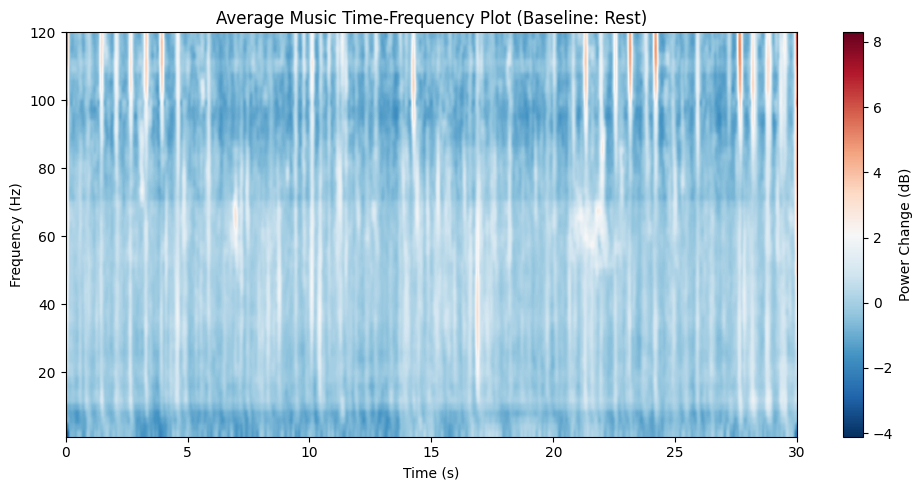

In [127]:
import matplotlib.pyplot as plt

# Use the same color scale as the speech plot
vmin = min(speech_db.min(), music_db.min())
vmax = max(speech_db.max(), music_db.max())

plt.figure(figsize=(10, 5))

plt.imshow(
    music_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Music Time-Frequency Plot (Baseline: Rest)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

In [128]:
rest_mean = rest_group_avg.mean(axis=1, keepdims=True)
rest_std  = rest_group_avg.std(axis=1, keepdims=True)

speech_z = (speech_group_avg - rest_mean) / rest_std
music_z  = (music_group_avg  - rest_mean) / rest_std

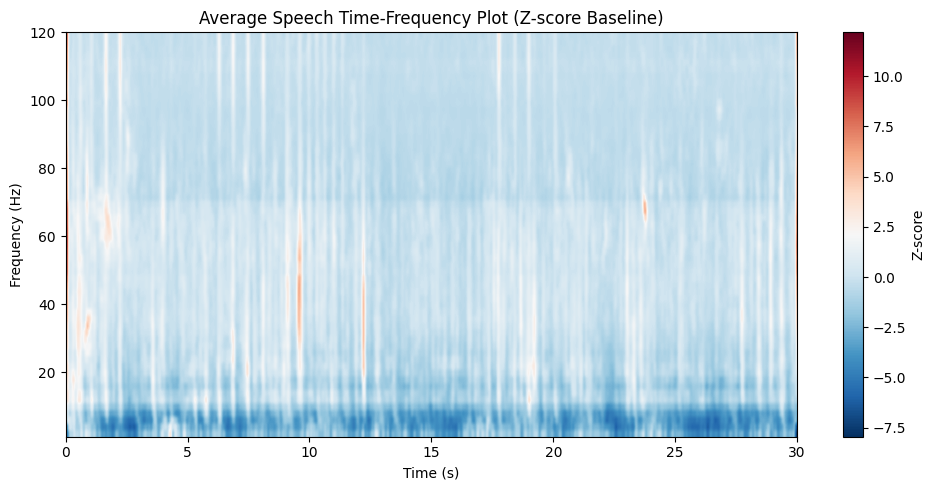

In [130]:
import matplotlib.pyplot as plt

# Common color scale
vmin = min(speech_z.min(), music_z.min())
vmax = max(speech_z.max(), music_z.max())

plt.figure(figsize=(10, 5))

plt.imshow(
    speech_z,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Speech Time-Frequency Plot (Z-score Baseline)")
plt.colorbar(label="Z-score")
plt.tight_layout()
plt.show()

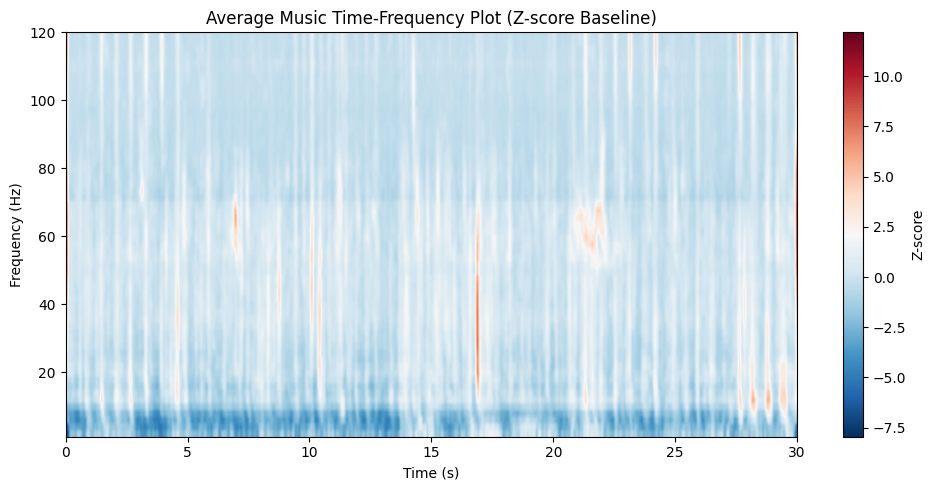

In [131]:
plt.figure(figsize=(10, 5))

plt.imshow(
    music_z,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Average Music Time-Frequency Plot (Z-score Baseline)")
plt.colorbar(label="Z-score")
plt.tight_layout()
plt.show()

In [25]:
# decim=4 means:

# keep every 4th time point,
# reducing memory by about 75%,
# while preserving the overall time-frequency pattern.

# For visualization and group averages, this is a common and reasonable choice.

In [26]:
# What does decim=4 actually do?

# Your original epoch has a sampling rate of 512 Hz.

# That means:

# Without decimation:
# 512 time points per second
# 30 seconds → 15,361 time points

# With

# decim=4

# MNE keeps every 4th time point.

# So now you have approximately:

# 512 / 4 = 128 Hz
# About 3,840 time points instead of 15,361.

# The frequency analysis is still performed over the same range (2–120 Hz); you're simply storing fewer time samples. For a 30-second visualization, this is usually more than sufficient and dramatically reduces memory usage.

frontal

In [134]:
# ---------------------------------------
# Subject groups
# ---------------------------------------

classification = {

    # Temporal
    "sub-16": "Temporal",
    "sub-17": "Temporal",
    "sub-20": "Temporal",
    "sub-22": "Temporal",
    "sub-24": "Temporal",
    "sub-26": "Temporal",
    "sub-27": "Temporal",
    "sub-28": "Temporal",
    "sub-34": "Temporal",
    "sub-36": "Temporal",
    "sub-39": "Temporal",
    "sub-40": "Temporal",
    "sub-45": "Temporal",
    "sub-46": "Temporal",
    "sub-48": "Temporal",
    "sub-49": "Temporal",
    "sub-51": "Temporal",
    "sub-54": "Temporal",
    "sub-57": "Temporal",
    "sub-58": "Temporal",
    "sub-59": "Temporal",
    "sub-60": "Temporal",

    # Fronto-Parietal
    "sub-01": "Fronto-Parietal",
    "sub-03": "Fronto-Parietal",
    "sub-06": "Fronto-Parietal",
    "sub-07": "Fronto-Parietal",
    "sub-14": "Fronto-Parietal",
    "sub-31": "Fronto-Parietal",
    "sub-37": "Fronto-Parietal",
    "sub-38": "Fronto-Parietal",
    "sub-41": "Fronto-Parietal",
    "sub-43": "Fronto-Parietal",

    # Frontal
    "sub-02": "Frontal",
    "sub-05": "Frontal",
    "sub-10": "Frontal",
    "sub-12": "Frontal",
    "sub-18": "Frontal",
    "sub-19": "Frontal",
    "sub-25": "Frontal",
    "sub-32": "Frontal",
    "sub-50": "Frontal",
    "sub-55": "Frontal",
    "sub-61": "Frontal",
    "sub-63": "Frontal",

    # Depth
    "sub-09": "Depth",
    "sub-13": "Depth",
    "sub-21": "Depth",
    "sub-23": "Depth",
    "sub-42": "Depth",

    # Mixed
    "sub-30": "Mixed",
}

# ---------------------------------------
# Create subject lists automatically
# ---------------------------------------

groups = {}

for subject, region in classification.items():
    groups.setdefault(region, []).append(subject)

for region in groups:
    groups[region] = sorted(groups[region])

print(groups.keys())

for region, subs in groups.items():
    print(region, len(subs))

dict_keys(['Temporal', 'Fronto-Parietal', 'Frontal', 'Depth', 'Mixed'])
Temporal 22
Fronto-Parietal 10
Frontal 12
Depth 5
Mixed 1


In [143]:
print(type(rest_epochs))

<class 'mne.epochs.Epochs'>


In [142]:
%who

BIDSPath	 Path	 acquisition	 best_channel	 bids_dir	 channel	 classification	 cmap	 data	 
datatype	 epoch	 epochs	 event_array	 event_files	 event_id	 event_ids	 events	 f	 
fif_file	 film_events	 freqs	 frontal_rest_epochs	 group_name	 group_subjects	 groups	 ieeg_dir	 mean_power	 
mne	 mne_bids	 mne_events	 music	 music_all	 music_db	 music_epochs	 music_group_avg	 music_tfr_data	 
music_z	 n_cycles	 np	 os	 pd	 plt	 preprocess_dir	 preprocessed_film	 preprocessed_rest	 
raw	 region	 region_df	 rest	 rest_all	 rest_baseline	 rest_epochs	 rest_epochs_dict	 rest_epochs_sub	 
rest_epochs_subject	 rest_files	 rest_group_avg	 rest_mean	 rest_std	 rest_tfr_data	 samples	 session	 sfreq	 
speech	 speech_all	 speech_avg	 speech_db	 speech_epochs	 speech_group_avg	 speech_music_epochs	 speech_tfr_data	 speech_z	 
start	 stats	 sub	 subject	 subject_name	 subjects	 subs	 template_tfr	 temporal_rest_epochs	 
temporal_subjects	 vmax	 vmin	 


In [ ]:
# For each subject
#     ↓
# Compute Speech TFR
# Compute Music TFR
# Compute Rest TFR
#     ↓
# Average across channels
#     ↓
# Store subject's power
# ---------------------------------
# After all subjects
#     ↓
# Average across subjects
#     ↓
# Compute average resting-state power
#     ↓
# Convert Speech and Music to dB
#     ↓
# Plot

Processing Subject 02...
✓ Finished Subject 02
Processing Subject 05...
✓ Finished Subject 05
Processing Subject 10...
✓ Finished Subject 10
Processing Subject 12...
✓ Finished Subject 12
Processing Subject 18...
✓ Finished Subject 18
Processing Subject 19...
✓ Finished Subject 19
Processing Subject 25...
✓ Finished Subject 25
Processing Subject 32...
✓ Finished Subject 32
Processing Subject 50...
✓ Finished Subject 50
Processing Subject 55...
✓ Finished Subject 55
Processing Subject 61...
✓ Finished Subject 61
Processing Subject 63...
✓ Finished Subject 63

Finished processing Frontal group!


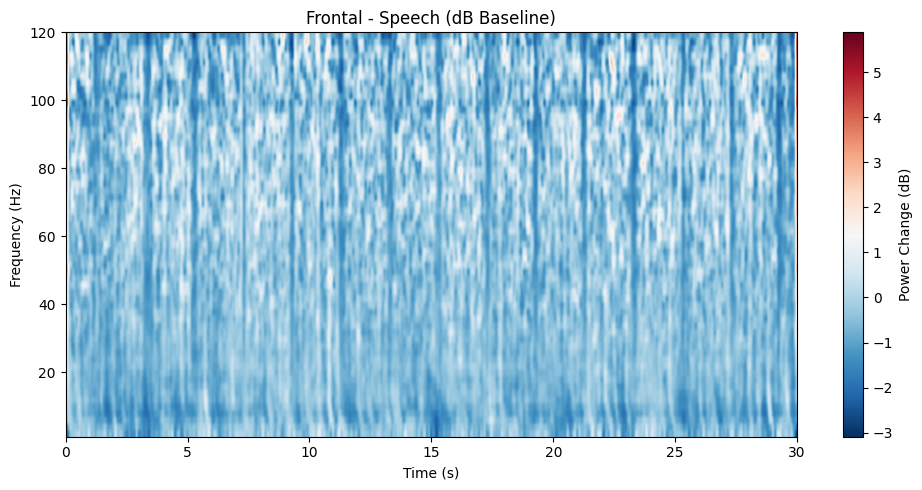

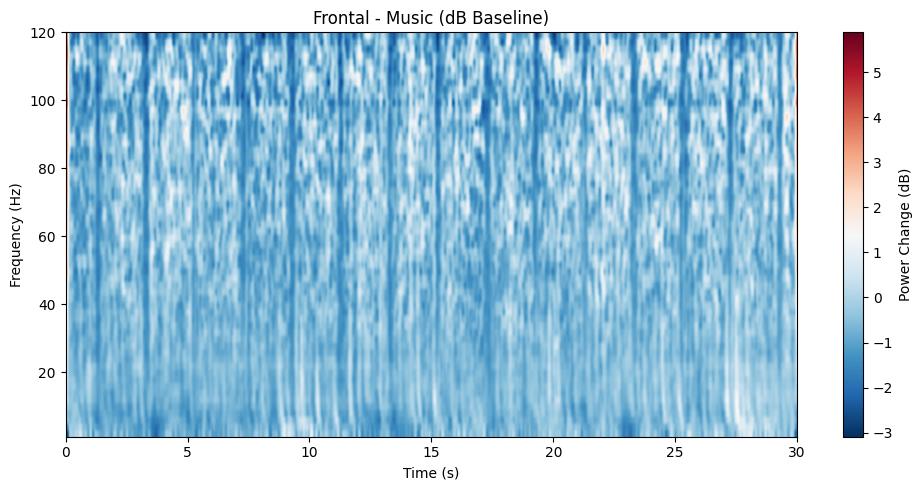

In [157]:
# ==========================================
# Compute TFRs for any anatomical group
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CHANGE ONLY THESE TWO LINES
# ---------------------------------------------------
group_name = "Frontal"
group_subjects = groups[group_name]
# ---------------------------------------------------

speech_tfr_data = {}
music_tfr_data = {}
rest_tfr_data = {}

template_tfr = None

for subject in sorted(group_subjects):

    subject = subject.replace("sub-", "")

    if subject not in group_rest_epochs[group_name]:
        print(f"Skipping {subject} (no resting-state data)")
        continue

    print(f"Processing Subject {subject}...")

    speech_epochs = speech_music_epochs[subject]["speech"]
    # music_epochs  = speech_music_epochs[subject]
    music_epochs = speech_music_epochs[subject]["music"]
    # rest_epochs   = rest_epochs_dict[subject]   # <-- use your group's rest dictionary
    rest_epochs = frontal_rest_epochs[subject]
    
    speech_tfr = speech_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    music_tfr = music_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    rest_tfr = rest_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    # Average across channels
    speech_tfr_data[subject] = speech_tfr.data.mean(axis=0)
    music_tfr_data[subject]  = music_tfr.data.mean(axis=0)
    rest_tfr_data[subject]   = rest_tfr.data.mean(axis=0)

    if template_tfr is None:
        template_tfr = speech_tfr.copy()

    del speech_tfr
    del music_tfr
    del rest_tfr

    print(f"✓ Finished Subject {subject}")

print(f"\nFinished processing {group_name} group!")

# =====================================================
# Average across subjects
# =====================================================

speech_all = np.stack(list(speech_tfr_data.values()), axis=0)
music_all  = np.stack(list(music_tfr_data.values()), axis=0)
rest_all   = np.stack(list(rest_tfr_data.values()), axis=0)

speech_group_avg = speech_all.mean(axis=0)
music_group_avg  = music_all.mean(axis=0)
rest_group_avg   = rest_all.mean(axis=0)

# =====================================================
# dB baseline using resting state
# =====================================================

rest_baseline = rest_group_avg.mean(axis=1, keepdims=True)

speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

# =====================================================
# Common color scale
# =====================================================

vmin = min(speech_db.min(), music_db.min())
vmax = max(speech_db.max(), music_db.max())

# =====================================================
# Plot Speech
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    speech_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Speech (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot Music
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    music_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Music (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

Processing Subject 01...
✓ Finished Subject 01
Processing Subject 03...
✓ Finished Subject 03
Processing Subject 06...
✓ Finished Subject 06
Processing Subject 07...
✓ Finished Subject 07
Processing Subject 14...
✓ Finished Subject 14
Processing Subject 31...
✓ Finished Subject 31
Processing Subject 37...
✓ Finished Subject 37
Processing Subject 38...
✓ Finished Subject 38
Processing Subject 41...
✓ Finished Subject 41
Processing Subject 43...
✓ Finished Subject 43

Finished processing Fronto-Parietal group!


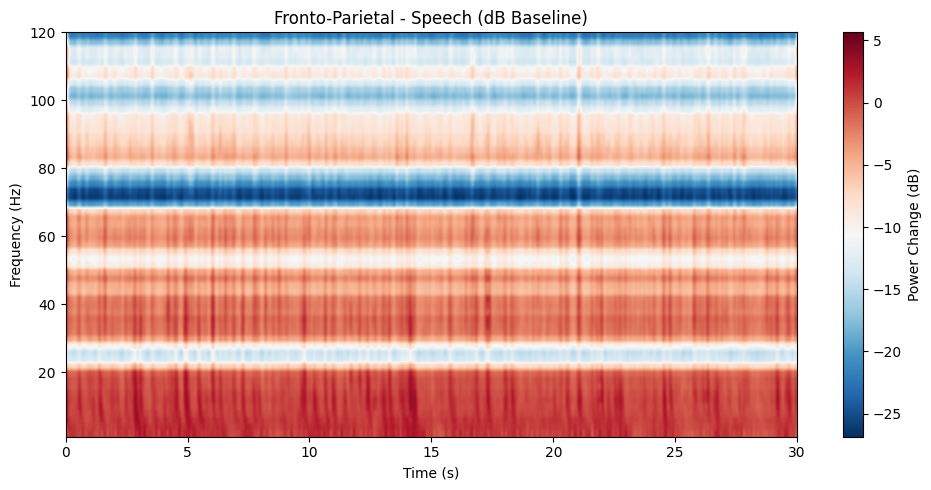

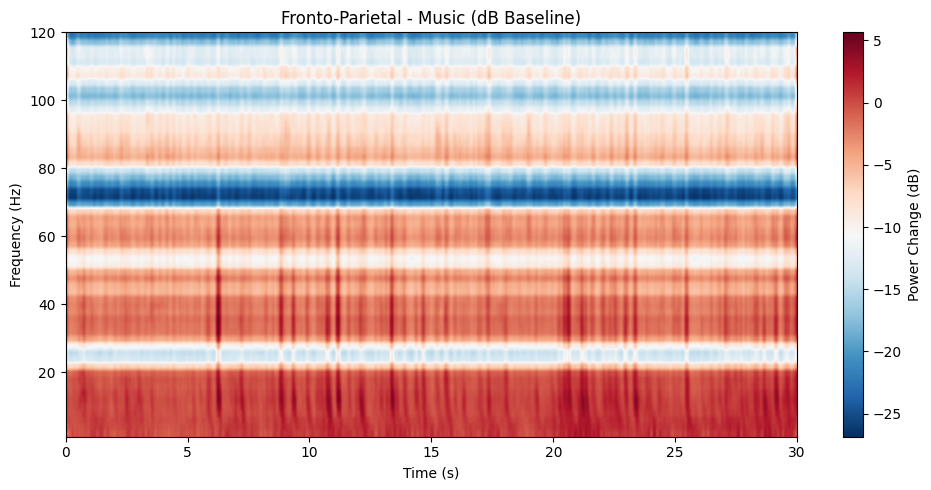

In [159]:
# ==========================================
# Compute TFRs for any anatomical group
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CHANGE ONLY THESE TWO LINES
# ---------------------------------------------------
group_name = "Fronto-Parietal"
group_subjects = groups[group_name]
# ---------------------------------------------------

speech_tfr_data = {}
music_tfr_data = {}
rest_tfr_data = {}

template_tfr = None

for subject in sorted(group_subjects):

    subject = subject.replace("sub-", "")

    if subject not in group_rest_epochs[group_name]:
        print(f"Skipping {subject} (no resting-state data)")
        continue

    print(f"Processing Subject {subject}...")

    speech_epochs = speech_music_epochs[subject]["speech"]
    # music_epochs  = speech_music_epochs[subject]
    music_epochs = speech_music_epochs[subject]["music"]
    # rest_epochs   = rest_epochs_dict[subject]   # <-- use your group's rest dictionary
    # rest_epochs = frontal_rest_epochs[subject]
    rest_epochs = group_rest_epochs[group_name][subject]
    
    speech_tfr = speech_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    music_tfr = music_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    rest_tfr = rest_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    # Average across channels
    speech_tfr_data[subject] = speech_tfr.data.mean(axis=0)
    music_tfr_data[subject]  = music_tfr.data.mean(axis=0)
    rest_tfr_data[subject]   = rest_tfr.data.mean(axis=0)

    if template_tfr is None:
        template_tfr = speech_tfr.copy()

    del speech_tfr
    del music_tfr
    del rest_tfr

    print(f"✓ Finished Subject {subject}")

print(f"\nFinished processing {group_name} group!")

# =====================================================
# Average across subjects
# =====================================================

speech_all = np.stack(list(speech_tfr_data.values()), axis=0)
music_all  = np.stack(list(music_tfr_data.values()), axis=0)
rest_all   = np.stack(list(rest_tfr_data.values()), axis=0)

speech_group_avg = speech_all.mean(axis=0)
music_group_avg  = music_all.mean(axis=0)
rest_group_avg   = rest_all.mean(axis=0)

# =====================================================
# dB baseline using resting state
# =====================================================

rest_baseline = rest_group_avg.mean(axis=1, keepdims=True)

speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

# =====================================================
# Common color scale
# =====================================================

vmin = min(speech_db.min(), music_db.min())
vmax = max(speech_db.max(), music_db.max())

# =====================================================
# Plot Speech
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    speech_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Speech (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot Music
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    music_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Music (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

Processing Subject 09...
✓ Finished Subject 09
Processing Subject 13...
✓ Finished Subject 13
Processing Subject 21...
✓ Finished Subject 21
Processing Subject 23...
✓ Finished Subject 23
Processing Subject 42...
✓ Finished Subject 42

Finished processing Depth group!


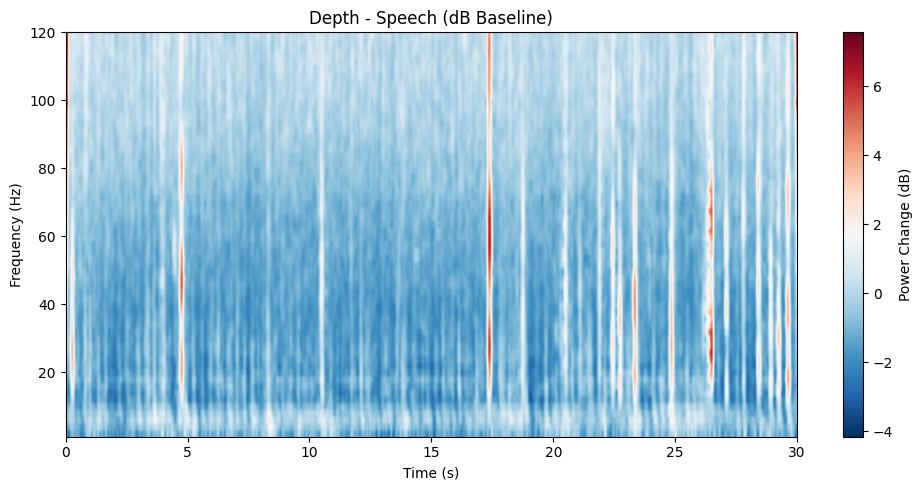

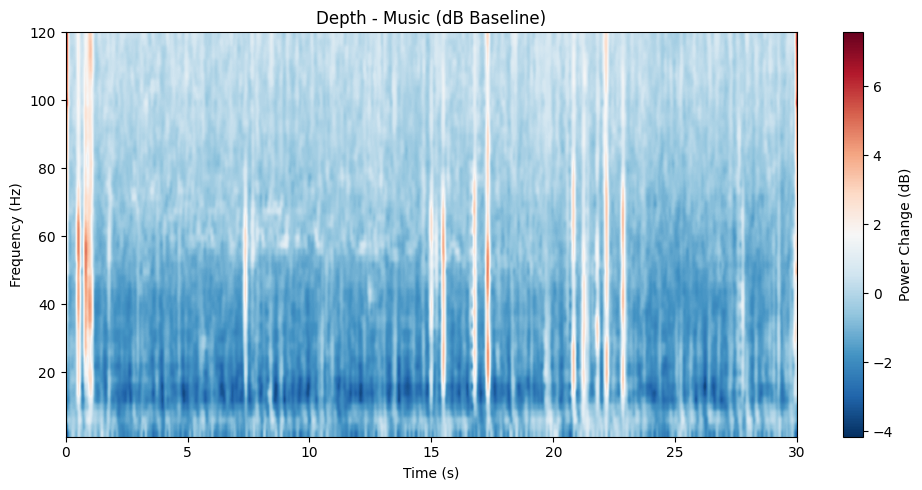

In [161]:
# ==========================================
# Compute TFRs for any anatomical group
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CHANGE ONLY THESE TWO LINES
# ---------------------------------------------------
group_name = "Depth"
group_subjects = groups[group_name]
# ---------------------------------------------------

speech_tfr_data = {}
music_tfr_data = {}
rest_tfr_data = {}

template_tfr = None

for subject in sorted(group_subjects):

    subject = subject.replace("sub-", "")

    if subject not in group_rest_epochs[group_name]:
        print(f"Skipping {subject} (no resting-state data)")
        continue

    print(f"Processing Subject {subject}...")

    speech_epochs = speech_music_epochs[subject]["speech"]
    # music_epochs  = speech_music_epochs[subject]
    music_epochs = speech_music_epochs[subject]["music"]
    # rest_epochs   = rest_epochs_dict[subject]   # <-- use your group's rest dictionary
    # rest_epochs = frontal_rest_epochs[subject]
    rest_epochs = group_rest_epochs[group_name][subject]
    
    speech_tfr = speech_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    music_tfr = music_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    rest_tfr = rest_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    # Average across channels
    speech_tfr_data[subject] = speech_tfr.data.mean(axis=0)
    music_tfr_data[subject]  = music_tfr.data.mean(axis=0)
    rest_tfr_data[subject]   = rest_tfr.data.mean(axis=0)

    if template_tfr is None:
        template_tfr = speech_tfr.copy()

    del speech_tfr
    del music_tfr
    del rest_tfr

    print(f"✓ Finished Subject {subject}")

print(f"\nFinished processing {group_name} group!")

# =====================================================
# Average across subjects
# =====================================================

speech_all = np.stack(list(speech_tfr_data.values()), axis=0)
music_all  = np.stack(list(music_tfr_data.values()), axis=0)
rest_all   = np.stack(list(rest_tfr_data.values()), axis=0)

speech_group_avg = speech_all.mean(axis=0)
music_group_avg  = music_all.mean(axis=0)
rest_group_avg   = rest_all.mean(axis=0)

# =====================================================
# dB baseline using resting state
# =====================================================

rest_baseline = rest_group_avg.mean(axis=1, keepdims=True)

speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

# =====================================================
# Common color scale
# =====================================================

vmin = min(speech_db.min(), music_db.min())
vmax = max(speech_db.max(), music_db.max())

# =====================================================
# Plot Speech
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    speech_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Speech (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot Music
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    music_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Music (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

Processing Subject 30...
✓ Finished Subject 30

Finished processing Mixed group!


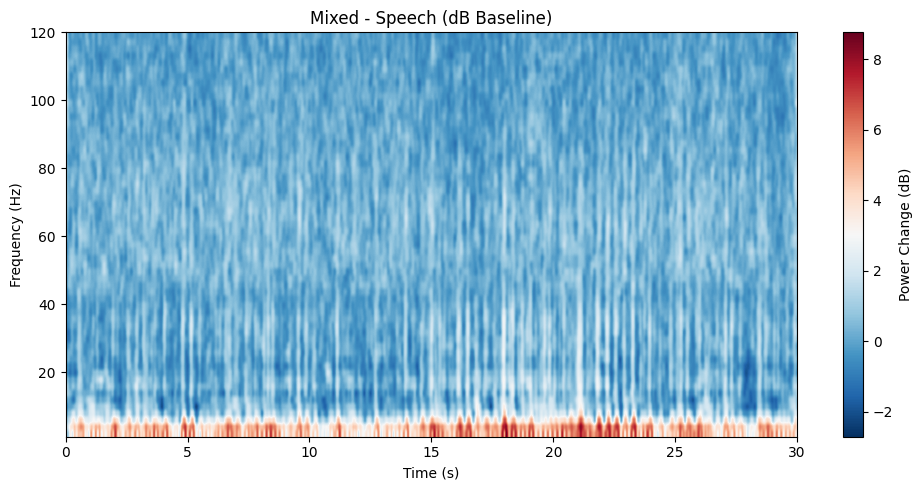

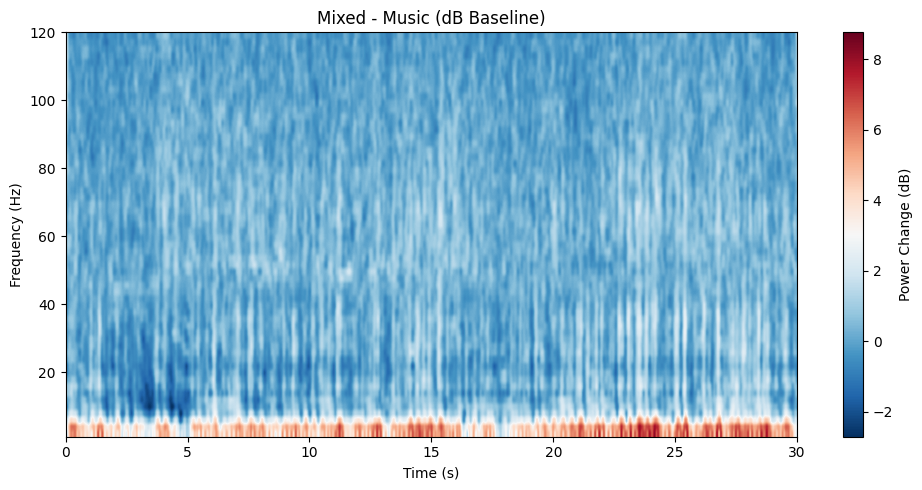

In [162]:
# ==========================================
# Compute TFRs for any anatomical group
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CHANGE ONLY THESE TWO LINES
# ---------------------------------------------------
group_name = "Mixed"
group_subjects = groups[group_name]
# ---------------------------------------------------

speech_tfr_data = {}
music_tfr_data = {}
rest_tfr_data = {}

template_tfr = None

for subject in sorted(group_subjects):

    subject = subject.replace("sub-", "")

    if subject not in group_rest_epochs[group_name]:
        print(f"Skipping {subject} (no resting-state data)")
        continue

    print(f"Processing Subject {subject}...")

    speech_epochs = speech_music_epochs[subject]["speech"]
    # music_epochs  = speech_music_epochs[subject]
    music_epochs = speech_music_epochs[subject]["music"]
    # rest_epochs   = rest_epochs_dict[subject]   # <-- use your group's rest dictionary
    # rest_epochs = frontal_rest_epochs[subject]
    rest_epochs = group_rest_epochs[group_name][subject]
    
    speech_tfr = speech_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    music_tfr = music_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    rest_tfr = rest_epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=False,
        decim=4,
        verbose=False,
    )

    # Average across channels
    speech_tfr_data[subject] = speech_tfr.data.mean(axis=0)
    music_tfr_data[subject]  = music_tfr.data.mean(axis=0)
    rest_tfr_data[subject]   = rest_tfr.data.mean(axis=0)

    if template_tfr is None:
        template_tfr = speech_tfr.copy()

    del speech_tfr
    del music_tfr
    del rest_tfr

    print(f"✓ Finished Subject {subject}")

print(f"\nFinished processing {group_name} group!")

# =====================================================
# Average across subjects
# =====================================================

speech_all = np.stack(list(speech_tfr_data.values()), axis=0)
music_all  = np.stack(list(music_tfr_data.values()), axis=0)
rest_all   = np.stack(list(rest_tfr_data.values()), axis=0)

speech_group_avg = speech_all.mean(axis=0)
music_group_avg  = music_all.mean(axis=0)
rest_group_avg   = rest_all.mean(axis=0)

# =====================================================
# dB baseline using resting state
# =====================================================

rest_baseline = rest_group_avg.mean(axis=1, keepdims=True)

speech_db = 10 * np.log10(speech_group_avg / rest_baseline)
music_db  = 10 * np.log10(music_group_avg  / rest_baseline)

# =====================================================
# Common color scale
# =====================================================

vmin = min(speech_db.min(), music_db.min())
vmax = max(speech_db.max(), music_db.max())

# =====================================================
# Plot Speech
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    speech_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Speech (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot Music
# =====================================================

plt.figure(figsize=(10,5))

plt.imshow(
    music_db,
    aspect="auto",
    origin="lower",
    extent=[
        template_tfr.times[0],
        template_tfr.times[-1],
        template_tfr.freqs[0],
        template_tfr.freqs[-1]
    ],
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"{group_name} - Music (dB Baseline)")
plt.colorbar(label="Power Change (dB)")
plt.tight_layout()
plt.show()